In [20]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import random
import os

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Config
INPUT_DIM = 128
OUTPUT_DIM = 8
SEQ_LEN = 12
PRED_LEN = 5
EPOCHS = 100   # Use higher for best results
BATCH_SIZE = 50
LR = 5e-5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [21]:
class CSIDataset(Dataset):
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path, header=None)
        self.scaler = StandardScaler()
        self.data = self.scaler.fit_transform(self.df.values)
    def __len__(self):
        return len(self.data) - SEQ_LEN - PRED_LEN
    def __getitem__(self, idx):
        x = self.data[idx:idx+SEQ_LEN]
        y = self.data[idx+SEQ_LEN:idx+SEQ_LEN+PRED_LEN]
        return torch.FloatTensor(x), torch.FloatTensor(y)

# CHANGE PATH for your scenario (e.g., 3km/h, 30km/h)
file_path = r"C:\Users\Aftab Dayer\Desktop\Thesis\dataset\UMA_128.csv"

dataset = CSIDataset(file_path)
n = len(dataset)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val
train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(seed))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


In [22]:
import torch.nn.functional as F

class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4):
        super().__init__()
        self.heads = heads
        self.W = nn.Linear(in_dim, heads*out_dim, bias=False)
        self.a = nn.Parameter(torch.randn(2*out_dim, 1))
    def forward(self, h):
        Wh = self.W(h).view(*h.shape[:2], self.heads, -1)
        e = torch.matmul(Wh, Wh.transpose(2,3)) / np.sqrt(Wh.size(-1))
        attention = F.softmax(e, dim=-1)
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime.view(*h.shape[:2], -1))

class EnhancedGAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GraphAttentionLayer(INPUT_DIM, 32)
        self.gat2 = GraphAttentionLayer(128, 64)
        self.tcn = nn.Conv1d(INPUT_DIM, 256, kernel_size=3, padding=1)
        self.fc = nn.Sequential(
            nn.Linear(256 + 256, 512),
            nn.ReLU(),
            nn.Linear(512, OUTPUT_DIM)
        )
    def forward(self, x):
        x_gat = self.gat1(x)
        x_gat = self.gat2(x_gat)
        x_tcn = self.tcn(x.permute(0,2,1))
        x_tcn = x_tcn.permute(0,2,1)
        combined = torch.cat([x_gat, x_tcn], dim=-1)
        return self.fc(combined[:, -1, :])


In [23]:
class LSTMNet(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, output_dim=8, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = hn[-1]
        return self.fc(out)


In [24]:
class CNNNet(nn.Module):
    def __init__(self, input_dim=128, output_dim=8):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32, output_dim)
    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.mean(dim=2)
        return self.fc(x)


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TemporalConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=1)
    def forward(self, x):
        # x: [B, T, F] -> [B, F, T]
        x = x.permute(0,2,1)
        x = self.conv(x)
        x = x.permute(0,2,1)
        return x

class SpatialAttention1D(nn.Module):
    def __init__(self, F):
        super().__init__()
        self.W = nn.Parameter(torch.randn(F, F))
    def forward(self, x):
        # x: [B, T, F]
        # Pool across time
        x_pool = torch.mean(x, dim=1)   # [B, F]
        attn = torch.matmul(torch.matmul(x_pool, self.W), x_pool.t())  # [B, B]
        attn = torch.softmax(attn, dim=-1)
        return attn

class STEMGNN(nn.Module):
    def __init__(self, F_in=INPUT_DIM, F_out=OUTPUT_DIM, hidden=64):
        super().__init__()
        self.temporal1 = TemporalConv1D(F_in, hidden)
        self.temporal2 = TemporalConv1D(hidden, hidden)
        self.fc = nn.Linear(hidden, F_out)
    def forward(self, x):
        # x: [B, T, F]
        t1 = F.relu(self.temporal1(x))   # [B, T, hidden]
        t2 = F.relu(self.temporal2(t1))  # [B, T, hidden]
        out = self.fc(t2[:,-1,:])        # Last timestep
        return out


In [26]:
def spectral_efficiency(y_true, y_pred, snr_db=30):
    noise_var = 10 ** (-snr_db / 10)
    signal_power = np.mean(np.linalg.norm(y_pred, axis=1)**2)
    interference = np.mean(np.linalg.norm(y_pred - y_true, axis=1)**2)
    sinr = signal_power / (interference + noise_var)
    return np.log2(1 + sinr)

def validate(model, loader, device, snr_db=30):
    model.eval()
    total_loss, total_rmse, total_se, batches = 0, 0, 0, 0
    criterion = nn.MSELoss()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y_true = y[:, -1, :OUTPUT_DIM].to(device)
            y_pred = model(x)
            loss = criterion(y_pred, y_true)
            y_true_np = y_true.cpu().numpy()
            y_pred_np = y_pred.detach().cpu().numpy()
            rmse = np.sqrt(mean_squared_error(y_true_np, y_pred_np))
            se = spectral_efficiency(y_true_np, y_pred_np, snr_db)
            total_loss += loss.item()
            total_rmse += rmse
            total_se += se
            batches += 1
    return total_loss / batches, total_rmse / batches, total_se / batches


In [27]:
def train_model(model, train_loader, val_loader, device, epochs=100, lr=5e-5, model_name='model'):
    optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    best_val_rmse = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_rmse': [], 'val_rmse': [], 'train_se': [], 'val_se': []}

    for epoch in range(epochs):
        model.train()
        total_loss, total_rmse, total_se, batches = 0, 0, 0, 0
        for x, y in train_loader:
            x = x.to(device)
            y_true = y[:, -1, :OUTPUT_DIM].to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y_true)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            y_true_np = y_true.cpu().numpy()
            y_pred_np = y_pred.detach().cpu().numpy()
            rmse = np.sqrt(mean_squared_error(y_true_np, y_pred_np))
            se = spectral_efficiency(y_true_np, y_pred_np)
            total_loss += loss.item()
            total_rmse += rmse
            total_se += se
            batches += 1
        avg_train_loss = total_loss / batches
        avg_train_rmse = total_rmse / batches
        avg_train_se = total_se / batches

        val_loss, val_rmse, val_se = validate(model, val_loader, device)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['train_rmse'].append(avg_train_rmse)
        history['val_rmse'].append(val_rmse)
        history['train_se'].append(avg_train_se)
        history['val_se'].append(val_se)

        print(f"{model_name} | Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f}, RMSE: {avg_train_rmse:.4f}, SE: {avg_train_se:.4f} | Val Loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}, SE: {val_se:.4f}")

        # Save best model (by val RMSE)
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f"==> {model_name} best model saved at epoch {epoch+1}")

    return history


In [28]:
stemgnn_model = STEMGNN(F_in=INPUT_DIM, F_out=OUTPUT_DIM, hidden=64).to(DEVICE)
stemgnn_history = train_model(stemgnn_model, train_loader, val_loader, DEVICE, epochs=EPOCHS, lr=LR, model_name='stemgnn')


gat_model = EnhancedGAT().to(DEVICE)
gat_history = train_model(gat_model, train_loader, val_loader, DEVICE, epochs=EPOCHS, lr=LR, model_name='gat')

lstm_model = LSTMNet().to(DEVICE)
lstm_history = train_model(lstm_model, train_loader, val_loader, DEVICE, epochs=EPOCHS, lr=LR, model_name='lstm')

cnn_model = CNNNet().to(DEVICE)
cnn_history = train_model(cnn_model, train_loader, val_loader, DEVICE, epochs=EPOCHS, lr=LR, model_name='cnn')



stemgnn | Epoch 1/100 | Train Loss: 0.8233, RMSE: 0.9055, SE: 0.0680 | Val Loss: 0.6965, RMSE: 0.8343, SE: 0.1731
==> stemgnn best model saved at epoch 1
stemgnn | Epoch 2/100 | Train Loss: 0.5749, RMSE: 0.7567, SE: 0.3694 | Val Loss: 0.4862, RMSE: 0.6970, SE: 0.5899
==> stemgnn best model saved at epoch 2
stemgnn | Epoch 3/100 | Train Loss: 0.3957, RMSE: 0.6278, SE: 0.8975 | Val Loss: 0.3394, RMSE: 0.5823, SE: 1.1656
==> stemgnn best model saved at epoch 3
stemgnn | Epoch 4/100 | Train Loss: 0.2777, RMSE: 0.5257, SE: 1.5021 | Val Loss: 0.2427, RMSE: 0.4923, SE: 1.7461
==> stemgnn best model saved at epoch 4
stemgnn | Epoch 5/100 | Train Loss: 0.2007, RMSE: 0.4469, SE: 2.0627 | Val Loss: 0.1770, RMSE: 0.4203, SE: 2.2811
==> stemgnn best model saved at epoch 5
stemgnn | Epoch 6/100 | Train Loss: 0.1470, RMSE: 0.3826, SE: 2.5767 | Val Loss: 0.1288, RMSE: 0.3585, SE: 2.7926
==> stemgnn best model saved at epoch 6
stemgnn | Epoch 7/100 | Train Loss: 0.1072, RMSE: 0.3266, SE: 3.0803 | Val L

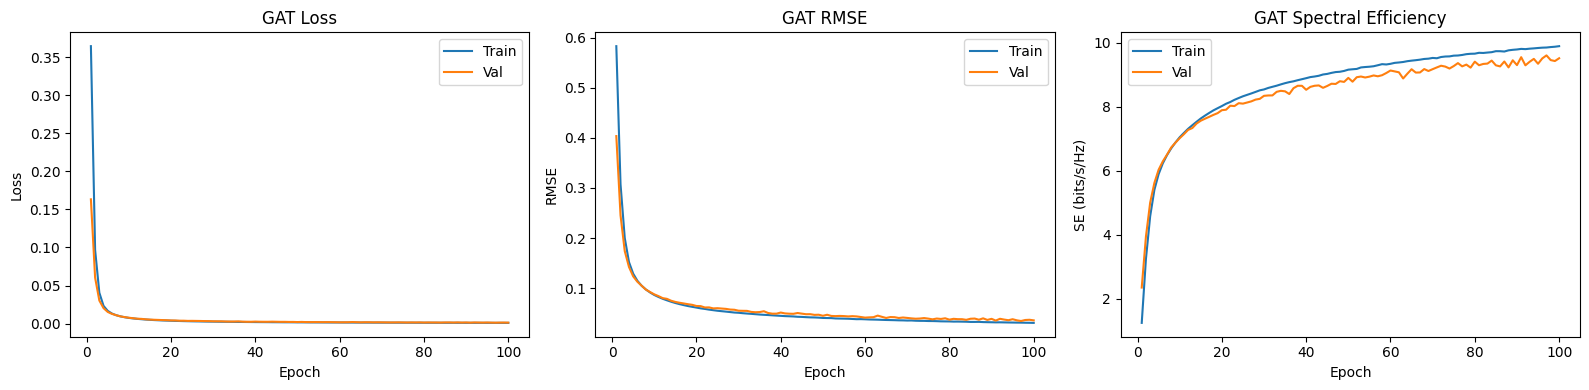

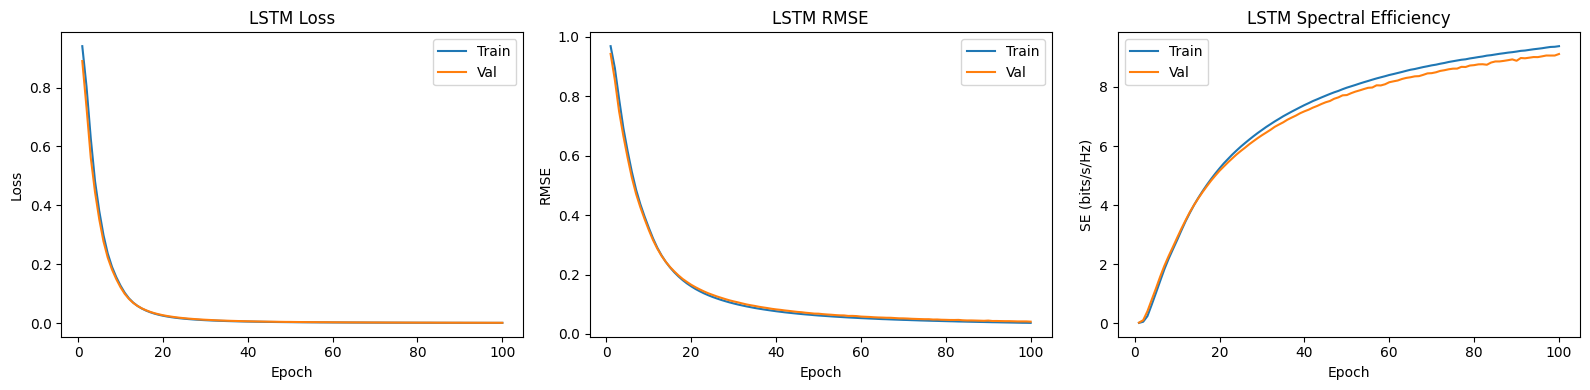

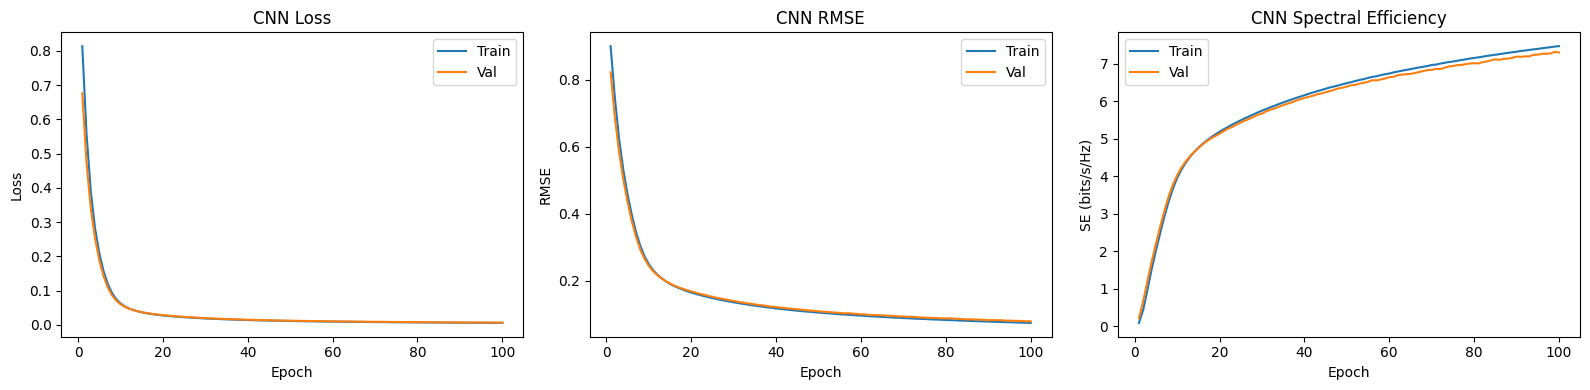

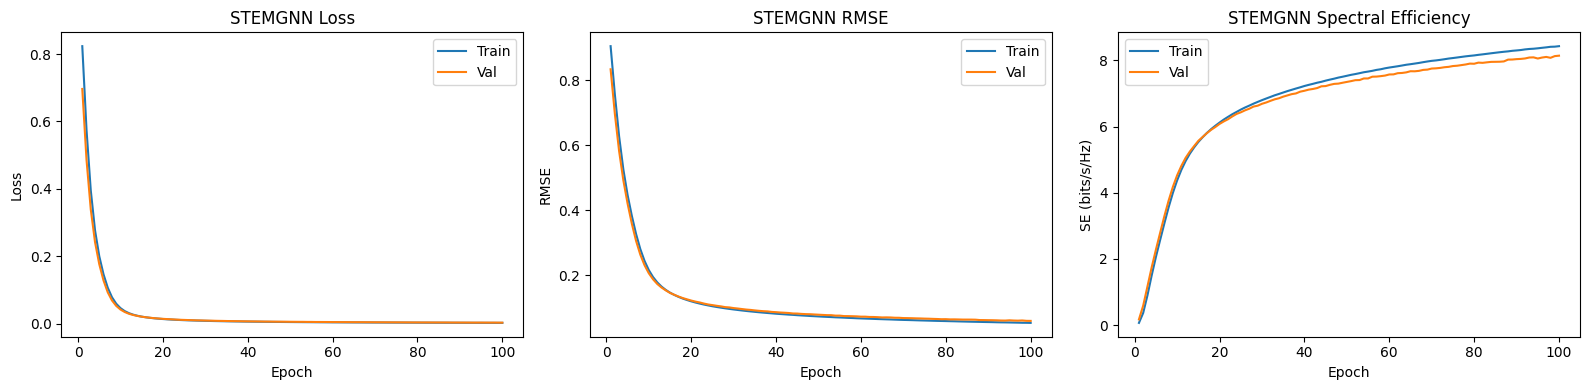

In [29]:
def plot_curves(history, model_name='Model'):
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(16,4))
    plt.subplot(1,3,1)
    plt.plot(epochs, history['train_loss'], label='Train')
    plt.plot(epochs, history['val_loss'], label='Val')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, history['train_rmse'], label='Train')
    plt.plot(epochs, history['val_rmse'], label='Val')
    plt.title(f'{model_name} RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs, history['train_se'], label='Train')
    plt.plot(epochs, history['val_se'], label='Val')
    plt.title(f'{model_name} Spectral Efficiency')
    plt.xlabel('Epoch')
    plt.ylabel('SE (bits/s/Hz)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_train_val_curves.png', dpi=300)
    plt.show()

plot_curves(gat_history, 'GAT')
plot_curves(lstm_history, 'LSTM')
plot_curves(cnn_history, 'CNN')
plot_curves(stemgnn_history, 'STEMGNN')


In [30]:
def evaluate_se_vs_ebn0(model, loader, device, ebn0_db_range):
    se_list = []
    model.eval()
    with torch.no_grad():
        for ebn0 in ebn0_db_range:
            total_se = 0
            count = 0
            for x, y in loader:
                x = x.to(device)
                y_true = y[:, -1, :OUTPUT_DIM].cpu().numpy()
                y_pred = model(x).cpu().numpy()
                se = spectral_efficiency(y_true, y_pred, snr_db=ebn0)
                total_se += se
                count += 1
            se_list.append(total_se / count)
    return se_list

ebn0_db_range = np.arange(0, 21, 2)

gat_best = EnhancedGAT().to(DEVICE)
gat_best.load_state_dict(torch.load('gat_best.pth', map_location=DEVICE))
lstm_best = LSTMNet().to(DEVICE)
lstm_best.load_state_dict(torch.load('lstm_best.pth', map_location=DEVICE))
cnn_best = CNNNet().to(DEVICE)
cnn_best.load_state_dict(torch.load('cnn_best.pth', map_location=DEVICE))
stemgnn_best = STEMGNN(F_in=INPUT_DIM, F_out=OUTPUT_DIM, hidden=64).to(DEVICE)
stemgnn_best.load_state_dict(torch.load('stemgnn_best.pth', map_location=DEVICE))


gat_test_se = evaluate_se_vs_ebn0(gat_best, test_loader, DEVICE, ebn0_db_range)
lstm_test_se = evaluate_se_vs_ebn0(lstm_best, test_loader, DEVICE, ebn0_db_range)
cnn_test_se = evaluate_se_vs_ebn0(cnn_best, test_loader, DEVICE, ebn0_db_range)
stemgnn_test_se = evaluate_se_vs_ebn0(stemgnn_best, test_loader, DEVICE, ebn0_db_range)


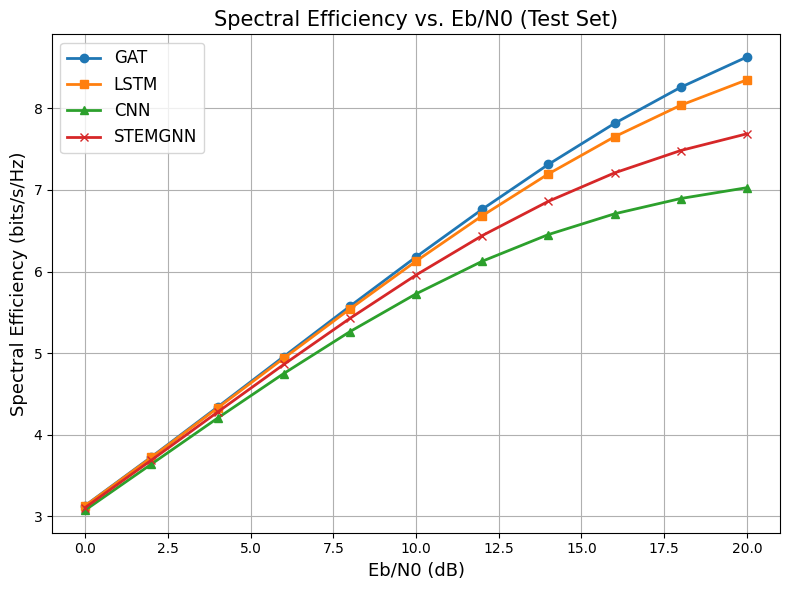

In [31]:
plt.figure(figsize=(8,6))
plt.plot(ebn0_db_range, gat_test_se, marker='o', linewidth=2, label='GAT')
plt.plot(ebn0_db_range, lstm_test_se, marker='s', linewidth=2, label='LSTM')
plt.plot(ebn0_db_range, cnn_test_se, marker='^', linewidth=2, label='CNN')
plt.plot(ebn0_db_range, stemgnn_test_se, marker='x', linewidth=2, label='STEMGNN')
plt.xlabel('Eb/N0 (dB)', fontsize=13)
plt.ylabel('Spectral Efficiency (bits/s/Hz)', fontsize=13)
plt.title('Spectral Efficiency vs. Eb/N0 (Test Set)', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison_se_vs_ebn0_with_stemgnn.png', dpi=300)
plt.show()


In [32]:
gat_loss, gat_rmse, gat_se = validate(gat_best, test_loader, DEVICE)
lstm_loss, lstm_rmse, lstm_se = validate(lstm_best, test_loader, DEVICE)
cnn_loss, cnn_rmse, cnn_se = validate(cnn_best, test_loader, DEVICE)
stemgnn_loss, stemgnn_rmse, stemgnn_se = validate(stemgnn_best, test_loader, DEVICE)

print("\nFinal Test Results (Eb/N0=30dB):")
print(f"GAT     | Loss: {gat_loss:.4f} | RMSE: {gat_rmse:.4f} | SE: {gat_se:.4f}")
print(f"LSTM    | Loss: {lstm_loss:.4f} | RMSE: {lstm_rmse:.4f} | SE: {lstm_se:.4f}")
print(f"CNN     | Loss: {cnn_loss:.4f} | RMSE: {cnn_rmse:.4f} | SE: {cnn_se:.4f}")
print(f"STEMGNN | Loss: {stemgnn_loss:.4f} | RMSE: {stemgnn_rmse:.4f} | SE: {stemgnn_se:.4f}")

print("\nEb/N0 (dB)\tGAT SE\tLSTM SE\tCNN SE\tSTEMGNN SE")
for ebn0, gse, lse, cse, sse in zip(ebn0_db_range, gat_test_se, lstm_test_se, cnn_test_se, stemgnn_test_se):
    print(f"{ebn0}\t\t{gse:.4f}\t{lse:.4f}\t{cse:.4f}\t{sse:.4f}")



Final Test Results (Eb/N0=30dB):
GAT     | Loss: 0.0012 | RMSE: 0.0352 | SE: 9.4970
LSTM    | Loss: 0.0018 | RMSE: 0.0422 | SE: 9.0179
CNN     | Loss: 0.0063 | RMSE: 0.0795 | SE: 7.2584
STEMGNN | Loss: 0.0035 | RMSE: 0.0595 | SE: 8.0731

Eb/N0 (dB)	GAT SE	LSTM SE	CNN SE	STEMGNN SE
0		3.1342	3.1313	3.0783	3.1095
2		3.7289	3.7225	3.6412	3.6895
4		4.3401	4.3283	4.2041	4.2779
6		4.9581	4.9379	4.7505	4.8613
8		5.5741	5.5411	5.2635	5.4260
10		6.1790	6.1269	5.7266	5.9573
12		6.7623	6.6830	6.1258	6.4399
14		7.3121	7.1955	6.4528	6.8600
16		7.8147	7.6505	6.7067	7.2082
18		8.2565	8.0365	6.8941	7.4819
20		8.6274	8.3477	7.0266	7.6864
